<a href="https://colab.research.google.com/github/jaylont/solar-microgrid-cyberattack-detection/blob/main/UpdatedCapstone_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Solar Microgrid Anomaly Detection
**Pinellas County, FL · FFNN Classifier · ISAT Capstone 2026**

This notebook covers:
1. Mount Drive & load model/data
2. Feature engineering
3. Realistic anomaly injection (6 attack types)
4. Inference & visualization
5. Streamlit GUI (ngrok tunnel for live demo)

In [ ]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2: Install dependencies
!pip install --upgrade keras tensorflow streamlit pyngrok -q

In [ ]:
# Cell 3: Imports & config
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

BASE = '/content/drive/MyDrive/Capstone_Microgrid/'

FEATURE_COLS = [
    'global_horizontal_irradiance', 'total_irradiance', 'soiled_irradiance',
    'dry_bulb_temperature', 'windspeed', 'avg_cell_temp',
    'module_power', 'optimal_dc_power', 'actual_dc_power',
    'ac_power', 'grid_power',
    'inverter_overpower_loss', 'inverter_underpower_loss',
    'inverter_overvoltage_loss', 'inverter_undervoltage_loss',
    'nameplate_power', 'location'
]

DERIVED = ['dc_efficiency', 'inverter_eff', 'grid_ac_ratio',
           'irr_to_power_ratio', 'temp_delta']

FINAL_FEATURES = FEATURE_COLS + DERIVED

CLASS_NAMES = ['Normal', 'Output Drop', 'Inverter Manip',
               'Sensor Spoof', 'Data Injection', 'Clipping Attack']

CLASS_COLORS = {
    'Normal':          '#2ecc71',
    'Output Drop':     '#e74c3c',
    'Inverter Manip':  '#e67e22',
    'Sensor Spoof':    '#9b59b6',
    'Data Injection':  '#3498db',
    'Clipping Attack': '#f1c40f',
    'Spike':           '#ff0066',
}

print('Config loaded.')

Config loaded.


In [ ]:
# ── Cell 4: Load model & data
scaler    = joblib.load(BASE + 'helioscope_scaler.pkl')
model     = keras.models.load_model(BASE + 'helioscope_anomaly_detector.keras')
df_market = pd.read_csv(BASE + 'Market_Parking_Lot_in_.csv')
df_park   = pd.read_csv(BASE + 'Public_Park_in_.csv')
print('Loaded successfully!')
print(f'  Market Lot: {len(df_market):,} rows')
print(f'  Public Park: {len(df_park):,} rows')

Loaded successfully!
  Market Lot: 8,760 rows
  Public Park: 8,760 rows


In [ ]:
# Cell 5: Feature engineering
def prepare_site(df, location_id):
    df = df.copy()
    df['location'] = location_id
    df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)
    eps = 1e-6
    df['dc_efficiency']      = (df['actual_dc_power']  / (df['optimal_dc_power'] + eps)).clip(0, 2)
    df['inverter_eff']       = (df['ac_power']          / (df['actual_dc_power']  + eps)).clip(0, 2)
    df['grid_ac_ratio']      = (df['grid_power']        / (df['ac_power']         + eps)).clip(0, 2)
    df['irr_to_power_ratio'] = (df['module_power']      / (df['total_irradiance'] + eps)).clip(0, 2)
    df['temp_delta']         = df['avg_cell_temp'] - df['dry_bulb_temperature']
    return df

df_market = prepare_site(df_market, 0)
df_park   = prepare_site(df_park,   1)
print('Features engineered.')

Features engineered.


In [ ]:
# Cell 6: Realistic anomaly injection
# All attacks restrict to daytime hours (grid actually generating)
# so that injections are physically plausible for Pinellas County.

def get_daytime_mask(df):
    """Hours where solar is generating above 30th percentile."""
    return df['grid_power'] > df['grid_power'].quantile(0.30)


def inject_output_drop(df, n=90, seed=42):
    """Suppresses grid_power AND ac_power to near-zero during daytime.
    Simulates total generation loss (e.g. islanding attack, breaker trip)."""
    np.random.seed(seed)
    mask = get_daytime_mask(df)
    idx  = np.random.choice(df[mask].index, size=min(n, mask.sum()), replace=False)
    df.loc[idx, 'grid_power'] = np.random.uniform(0, 500, size=len(idx))
    df.loc[idx, 'ac_power']   = np.random.uniform(0, 300, size=len(idx))
    return df, idx


def inject_inverter_manip(df, n=80, seed=42):
    """Degrades AC output relative to DC — inverter efficiency anomaly.
    Simulates firmware manipulation or forced derating."""
    np.random.seed(seed)
    mask = get_daytime_mask(df)
    idx  = np.random.choice(df[mask].index, size=min(n, mask.sum()), replace=False)
    df.loc[idx, 'ac_power'] = (
        df.loc[idx, 'actual_dc_power'] * np.random.uniform(0.1, 0.4, size=len(idx))
    )
    return df, idx


def inject_sensor_spoof(df, n=70, seed=42):
    """Zeros all irradiance sensors while power output continues normally.
    Simulates a spoofed weather station reporting no sun during generation."""
    np.random.seed(seed)
    mask = get_daytime_mask(df)
    idx  = np.random.choice(df[mask].index, size=min(n, mask.sum()), replace=False)
    df.loc[idx, 'global_horizontal_irradiance'] = 0
    df.loc[idx, 'total_irradiance']             = 0
    df.loc[idx, 'soiled_irradiance']            = 0
    return df, idx


def inject_data_injection(df, n=60, seed=42):
    """Replaces contiguous windows with suspiciously flat constant values.
    More realistic than random scatter — mirrors replay attack patterns."""
    np.random.seed(seed)
    injected_idx = []
    window_size  = max(3, n // 5)
    n_windows    = max(1, n // window_size)
    starts = np.random.choice(range(0, len(df) - window_size), size=n_windows, replace=False)
    for s in starts:
        window   = list(range(s, s + window_size))
        flat_val = df['grid_power'].iloc[s] * np.random.uniform(0.85, 1.15)
        df.loc[window, 'grid_power'] = flat_val
        injected_idx.extend(window)
    return df, np.array(injected_idx[:n])


def inject_clipping(df, n=30, seed=42):
    """Locks grid_power to exactly the nameplate ceiling — physically implausible
    sustained flat-top pattern that real systems never hold."""
    np.random.seed(seed)
    mask    = get_daytime_mask(df)
    idx     = np.random.choice(df[mask].index, size=min(n, mask.sum()), replace=False)
    ceiling = df['nameplate_power'].median()
    df.loc[idx, 'grid_power'] = ceiling
    return df, idx


def inject_spike(df, n=60, multiplier=2.0, seed=42):
    """Injects readings above the normal output ceiling during daytime only.
    Simulates false high readings injected into SCADA (e.g. 2-3x normal max)."""
    np.random.seed(seed)
    mask       = get_daytime_mask(df)
    idx        = np.random.choice(df[mask].index, size=min(n, mask.sum()), replace=False)
    normal_max = df['grid_power'].max()
    df.loc[idx, 'grid_power'] = (
        normal_max * np.random.uniform(multiplier * 0.9, multiplier * 1.1, size=len(idx))
    )
    return df, idx


# ── Choose your attack here ──────────────────────────────────────────────────
ATTACK   = 'Spike', 'Sensor Spoof', 'Inverter Manip', 'Clipping Attack'         # Options: 'Output Drop', 'Inverter Manip', 'Sensor Spoof',
                             #          'Data Injection', 'Clipping Attack', 'Spike'
N_INJECT = 90               # How many anomalous points to inject
SPIKE_MULTIPLIER = 2.0      # Only used when ATTACK == 'Spike'

df_market_inj = df_market.copy()

if ATTACK == 'Output Drop':
    df_market_inj, injected_idx = inject_output_drop(df_market_inj, N_INJECT)
elif ATTACK == 'Inverter Manip':
    df_market_inj, injected_idx = inject_inverter_manip(df_market_inj, N_INJECT)
elif ATTACK == 'Sensor Spoof':
    df_market_inj, injected_idx = inject_sensor_spoof(df_market_inj, N_INJECT)
elif ATTACK == 'Data Injection':
    df_market_inj, injected_idx = inject_data_injection(df_market_inj, N_INJECT)
elif ATTACK == 'Clipping Attack':
    df_market_inj, injected_idx = inject_clipping(df_market_inj, N_INJECT)
elif ATTACK == 'Spike':
    df_market_inj, injected_idx = inject_spike(df_market_inj, N_INJECT, SPIKE_MULTIPLIER)

# Recalculate derived features after injection
df_market_inj = prepare_site(df_market_inj, 0)

print(f'Injected {len(injected_idx)} "{ATTACK}" anomalies into Market Lot data.')

Injected 30 "('Spike', 'Sensor Spoof', 'Inverter Manip', 'Clipping Attack')" anomalies into Market Lot data.


In [ ]:
# Cell 7: Run inference
df_all = pd.concat([df_market_inj, df_park], ignore_index=True)

X     = scaler.transform(df_all[FINAL_FEATURES].values)
preds = model.predict(X, verbose=1)

df_all['predicted_class'] = preds.argmax(axis=1)
df_all['confidence']      = preds.max(axis=1)
df_all['anomaly_label']   = df_all['predicted_class'].map(dict(enumerate(CLASS_NAMES)))

print('\nClass distribution:')
print(df_all['anomaly_label'].value_counts())

548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Class distribution:
anomaly_label
Normal          17506
Sensor Spoof       14
Name: count, dtype: int64


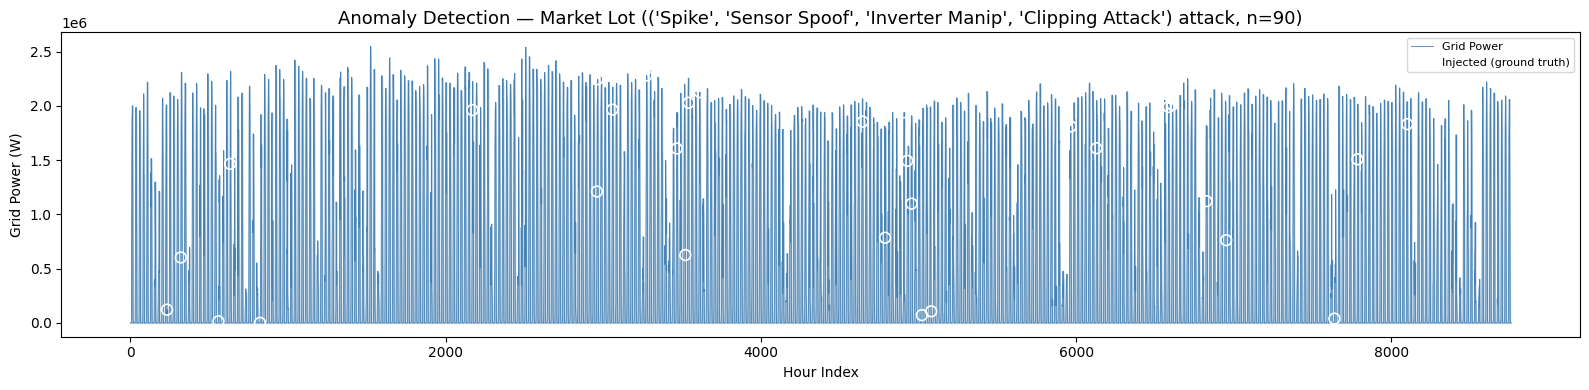

In [ ]:
# Cell 8: Visualize results
market_df  = df_all[df_all['location'] == 0].reset_index(drop=True)
anomaly_df = market_df[market_df['predicted_class'] > 0]

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(range(len(market_df)), market_df['grid_power'], alpha=0.35, color='steelblue')
ax.plot(market_df['grid_power'].values, color='steelblue', linewidth=0.6, label='Grid Power')

# Each anomaly class plotted in its own color
for cls in CLASS_NAMES[1:]:
    sub = anomaly_df[anomaly_df['anomaly_label'] == cls]
    if not sub.empty:
        ax.scatter(sub.index, sub['grid_power'],
                   color=CLASS_COLORS.get(cls, 'red'), s=18, zorder=5, label=cls)

# White rings around the injected ground-truth points
valid = [i for i in injected_idx if i < len(market_df)]
ax.scatter(valid, market_df.loc[valid, 'grid_power'],
           facecolors='none', edgecolors='white', s=60,
           linewidths=1.2, zorder=6, label='Injected (ground truth)')

ax.set_title(f'Anomaly Detection — Market Lot ({ATTACK} attack, n={N_INJECT})', fontsize=13)
ax.set_xlabel('Hour Index')
ax.set_ylabel('Grid Power (W)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

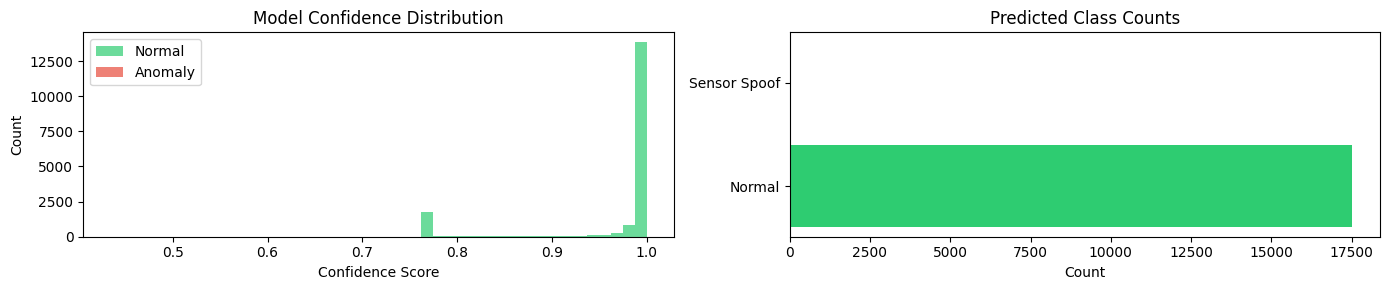

Total readings:      17,520
Anomalies detected:  14  (0.1%)
Avg confidence:      96.8%
Injected anomalies:  30


In [ ]:
# Cell 9: Confidence distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# Confidence histogram
normal_conf = df_all[df_all['predicted_class'] == 0]['confidence']
anom_conf   = df_all[df_all['predicted_class'] >  0]['confidence']
axes[0].hist(normal_conf, bins=40, color='#2ecc71', alpha=0.7, label='Normal')
axes[0].hist(anom_conf,   bins=40, color='#e74c3c', alpha=0.7, label='Anomaly')
axes[0].set_title('Model Confidence Distribution')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Class bar chart
counts = df_all['anomaly_label'].value_counts()
colors = [CLASS_COLORS.get(c, '#888') for c in counts.index]
axes[1].barh(counts.index, counts.values, color=colors)
axes[1].set_title('Predicted Class Counts')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Summary stats
total      = len(df_all)
n_detected = (df_all['predicted_class'] > 0).sum()
print(f'Total readings:      {total:,}')
print(f'Anomalies detected:  {n_detected:,}  ({n_detected/total*100:.1f}%)')
print(f'Avg confidence:      {df_all["confidence"].mean()*100:.1f}%')
print(f'Injected anomalies:  {len(injected_idx)}')

In [ ]:
# Cell 10: Write Streamlit app to disk
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from tensorflow import keras

st.set_page_config(page_title="Solar Microgrid Anomaly Detection", page_icon="⚡", layout="wide")
st.title("Solar Microgrid Anomaly Detection")
st.caption("Pinellas County, FL ISAT Capstone 2026")

BASE = "/content/drive/MyDrive/Capstone_Microgrid/"

FEATURE_COLS = [
    "global_horizontal_irradiance", "total_irradiance", "soiled_irradiance",
    "dry_bulb_temperature", "windspeed", "avg_cell_temp",
    "module_power", "optimal_dc_power", "actual_dc_power",
    "ac_power", "grid_power",
    "inverter_overpower_loss", "inverter_underpower_loss",
    "inverter_overvoltage_loss", "inverter_undervoltage_loss",
    "nameplate_power", "location"
]
DERIVED = ["dc_efficiency", "inverter_eff", "grid_ac_ratio", "irr_to_power_ratio", "temp_delta"]
FINAL_FEATURES = FEATURE_COLS + DERIVED
CLASS_NAMES  = ["Normal", "Output Drop", "Inverter Manip", "Sensor Spoof", "Data Injection", "Clipping Attack"]
CLASS_COLORS = {
    "Normal": "#2ecc71", "Output Drop": "#e74c3c", "Inverter Manip": "#e67e22",
    "Sensor Spoof": "#9b59b6", "Data Injection": "#3498db",
    "Clipping Attack": "#f1c40f", "Spike": "#ff0066",
}

def prepare_site(df, location_id):
    df = df.copy()
    df["location"] = location_id
    df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)
    eps = 1e-6
    df["dc_efficiency"]      = (df["actual_dc_power"]  / (df["optimal_dc_power"] + eps)).clip(0, 2)
    df["inverter_eff"]       = (df["ac_power"]          / (df["actual_dc_power"]  + eps)).clip(0, 2)
    df["grid_ac_ratio"]      = (df["grid_power"]        / (df["ac_power"]         + eps)).clip(0, 2)
    df["irr_to_power_ratio"] = (df["module_power"]      / (df["total_irradiance"] + eps)).clip(0, 2)
    df["temp_delta"]         = df["avg_cell_temp"] - df["dry_bulb_temperature"]
    return df

def get_daytime_mask(df):
    return df["grid_power"] > df["grid_power"].quantile(0.30)

# ── Load data once and cache ─────────────────────────────────────────────────
@st.cache_resource
def load_model_and_data():
    scaler    = joblib.load(BASE + "helioscope_scaler.pkl")
    model     = keras.models.load_model(BASE + "helioscope_anomaly_detector.keras")
    df_market = prepare_site(pd.read_csv(BASE + "Market_Parking_Lot_in_.csv"), 0)
    df_park   = prepare_site(pd.read_csv(BASE + "Public_Park_in_.csv"), 1)
    df_all    = pd.concat([df_market, df_park], ignore_index=True)
    X         = scaler.transform(df_all[FINAL_FEATURES].values)
    preds     = model.predict(X, verbose=0)
    df_all["predicted_class"] = preds.argmax(axis=1)
    df_all["confidence"]      = preds.max(axis=1)
    df_all["anomaly_label"]   = df_all["predicted_class"].map(dict(enumerate(CLASS_NAMES)))
    return df_all

with st.spinner("Loading model and running inference..."):
    df_all = load_model_and_data()

max_hours = len(df_all[df_all["location"] == 0]) - 1

# ── Sidebar controls ─────────────────────────────────────────────────────────
with st.sidebar:
    st.header("Controls")
    st.markdown("---")

    st.subheader("Site")
    site_choice = st.radio("Select site", ["Market Parking Lot", "Public Park", "Both"])

    st.markdown("---")
    st.subheader("Time Window")
    time_window = st.slider("Hour index range", 0, max_hours, (0, max_hours))

    st.markdown("---")
    st.subheader("Confidence Threshold")
    conf_threshold = st.slider("Min confidence to display anomaly", 0, 100, 50)

    st.markdown("---")
    st.subheader("Anomaly Class Filter")
    selected_classes = []
    for cls in CLASS_NAMES[1:]:
        if st.checkbox(cls, value=True, key=cls):
            selected_classes.append(cls)

# ── Filter based on controls ─────────────────────────────────────────────────
site_map = {"Market Parking Lot": 0, "Public Park": 1}
if site_choice == "Both":
    plot_df = df_all.copy()
else:
    plot_df = df_all[df_all["location"] == site_map[site_choice]].copy()

plot_df    = plot_df.reset_index(drop=True).iloc[time_window[0]:time_window[1]].reset_index(drop=True)
anomaly_df = plot_df[
    (plot_df["predicted_class"] > 0) &
    (plot_df["confidence"] >= conf_threshold / 100) &
    (plot_df["anomaly_label"].isin(selected_classes))
]

# ── KPI row ───────────────────────────────────────────────────────────────────
total      = len(plot_df)
n_detected = len(anomaly_df)
avg_conf   = plot_df["confidence"].mean() * 100
k1, k2, k3, k4 = st.columns(4)
k1.metric("Readings in Window",  f"{total:,}")
k2.metric("Anomalies Detected",  f"{n_detected:,}", f"{n_detected/max(total,1)*100:.1f}% of window")
k3.metric("Avg Confidence",      f"{avg_conf:.1f}%")
k4.metric("Site",                site_choice)

# ── Main plot ─────────────────────────────────────────────────────────────────
st.markdown("### Grid Power with Anomaly Overlay")
fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(range(len(plot_df)), plot_df["grid_power"], alpha=0.35, color="steelblue")
ax.plot(plot_df["grid_power"].values, color="steelblue", linewidth=0.6, label="Grid Power")
for cls in selected_classes:
    sub = anomaly_df[anomaly_df["anomaly_label"] == cls]
    if not sub.empty:
        ax.scatter(sub.index, sub["grid_power"],
                   color=CLASS_COLORS.get(cls, "red"), s=18, zorder=5, label=cls)
ax.set_xlabel("Hour Index"); ax.set_ylabel("Grid Power (W)")
ax.set_title(f"Anomaly Detection — {site_choice} (Hours {time_window[0]}–{time_window[1]})", fontsize=13)
ax.legend(loc="upper right", fontsize=8)
ax.set_facecolor("#0e1117"); fig.patch.set_facecolor("#0e1117")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("#444")
st.pyplot(fig)

# ── Class distribution + confidence histogram ─────────────────────────────────
col_l, col_r = st.columns([1, 2])
counts = anomaly_df["anomaly_label"].value_counts().reset_index()
counts.columns = ["Class", "Count"]
counts["%"] = (counts["Count"] / max(total, 1) * 100).round(2)
col_l.markdown("### Class Distribution")
col_l.dataframe(counts, use_container_width=True, hide_index=True)
with col_r:
    st.markdown("### Confidence Distribution")
    fig2, ax2 = plt.subplots(figsize=(7, 2.5))
    ax2.hist(plot_df[plot_df["predicted_class"]==0]["confidence"], bins=40, color="#2ecc71", alpha=0.7, label="Normal")
    ax2.hist(plot_df[plot_df["predicted_class"]>0]["confidence"],  bins=40, color="#e74c3c", alpha=0.7, label="Anomaly")
    ax2.axvline(conf_threshold / 100, color="white", linestyle="--", linewidth=1, label=f"Threshold ({conf_threshold}%)")
    ax2.set_facecolor("#0e1117"); fig2.patch.set_facecolor("#0e1117")
    ax2.tick_params(colors="white"); ax2.legend(fontsize=8)
    for spine in ax2.spines.values(): spine.set_edgecolor("#444")
    st.pyplot(fig2)

# ── Raw anomaly table ─────────────────────────────────────────────────────────
with st.expander("Raw Anomaly Records"):
    tbl = anomaly_df[["grid_power", "ac_power", "global_horizontal_irradiance",
                      "anomaly_label", "confidence", "location"]].copy()
    tbl["location"]   = tbl["location"].map({0: "Market Lot", 1: "Public Park"})
    tbl["confidence"] = (tbl["confidence"] * 100).round(1).astype(str) + "%"
    st.dataframe(tbl.reset_index(drop=True), use_container_width=True)
'''

with open('/content/capstone_app.py', 'w') as f:
    f.write(app_code)

print('Streamlit app written to /content/capstone_app.py')

Streamlit app written to /content/capstone_app.py
